In [ ]:
# Install imbalanced-learn library for SMOTE
!pip install imbalanced-learn

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

In [ ]:
# Load Dataset
df = pd.read_csv('/content/creditcard.csv')
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (55551, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

     

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55551 entries, 0 to 55550
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    55551 non-null  int64  
 1   V1      55551 non-null  float64
 2   V2      55551 non-null  float64
 3   V3      55551 non-null  float64
 4   V4      55551 non-null  float64
 5   V5      55551 non-null  float64
 6   V6      55551 non-null  float64
 7   V7      55551 non-null  float64
 8   V8      55551 non-null  float64
 9   V9      55551 non-null  float64
 10  V10     55551 non-null  float64
 11  V11     55551 non-null  float64
 12  V12     55551 non-null  float64
 13  V13     55551 non-null  float64
 14  V14     55551 non-null  float64
 15  V15     55550 non-null  float64
 16  V16     55550 non-null  float64
 17  V17     55550 non-null  float64
 18  V18     55550 non-null  float64
 19  V19     55550 non-null  float64
 20  V20     55550 non-null  float64
 21  V21     55550 non-null  float64
 22

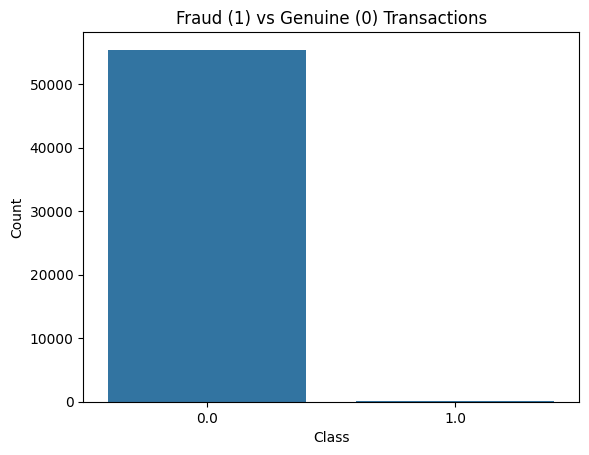

In [ ]:
# Explore Dataset
print(df.info())
print("\nClass Distribution:\n", df['Class'].value_counts())

# Visualize Class Distribution
sns.countplot(x='Class', data=df)
plt.title("Fraud (1) vs Genuine (0) Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
# Handle missing values
print("Missing values in each column:\n", df.isnull().sum())

# Drop rows only if target column (Class) has NaN
df = df.dropna(subset=['Class'])

# Fill remaining missing values in feature columns with median
df = df.fillna(df.median(numeric_only=True))

print("\nShape after handling missing values:", df.shape)

Missing values in each column:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64

Shape after handling missing values: (55550, 31)


In [ ]:
# Preprocess Data
scaler = StandardScaler()
df['normAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['normTime'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (38885, 30)
Testing Set: (16665, 30)


In [ ]:
# Handle Class Imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("After SMOTE:\n", y_train_res.value_counts())

Before SMOTE:
 Class
0.0    38776
1.0      109
Name: count, dtype: int64
After SMOTE:
 Class
0.0    38776
1.0    38776
Name: count, dtype: int64


In [ ]:
# Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# Evaluate Model
def evaluate_model(name, y_true, y_pred):
    print(f"\n {name} Results ")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Random Forest", y_test, y_pred_rf)


 Random Forest Results 
Accuracy : 0.9993399339933994
Precision: 0.9090909090909091
Recall   : 0.851063829787234
F1 Score : 0.8791208791208791
Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     16618
         1.0       0.91      0.85      0.88        47

    accuracy                           1.00     16665
   macro avg       0.95      0.93      0.94     16665
weighted avg       1.00      1.00      1.00     16665



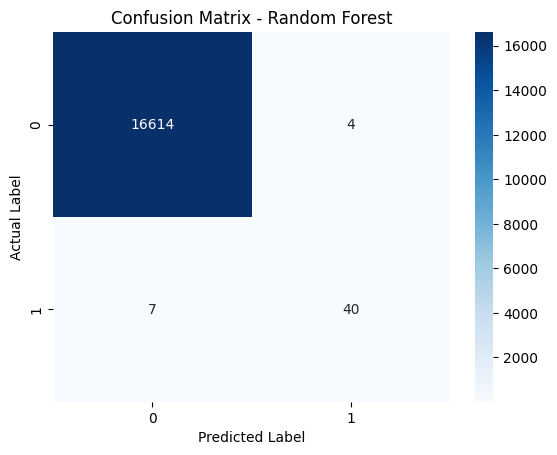

In [ ]:
# Visualize Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [ ]:
# Test on Sample Transactions
sample = X_test.sample(5, random_state=1)
sample_actual = y_test.loc[sample.index]
sample_pred = rf_model.predict(sample)

result = pd.DataFrame({'Actual': sample_actual.values, 'Predicted': sample_pred})
print(result)

   Actual  Predicted
0     0.0        0.0
1     0.0        0.0
2     0.0        0.0
3     0.0        0.0
4     0.0        0.0


In [ ]:
# Test a Single Custom Transaction
custom_transaction = X_test.iloc[0:1]
prediction = rf_model.predict(custom_transaction)

print("\nResult:", "Genuine Transaction " if prediction[0] == 0 else "Fraudulent Transaction ")


Result: Genuine Transaction 


In [ ]:
# Save Model and Scaler
import joblib
joblib.dump(rf_model, 'fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']